# 07b · GSE65391 · RNA_array · heatmap of every visit, each child's visits together

Reads `modules.rds`, `wgcna_input.rds`, `expression.rds`, `projected_scores.rds` (for the metadata).

**Samples.** All 972 array samples: 924 SLE samples from 158 children (every visit) and 48 samples
from 46 healthy children, as a reference block.

**Matrix.** The same hub genes as notebooks 07 and 08. Each gene is standardised with the mean and SD
of the 157 first visits, the scaling used to fit the modules (notebook 05b), so colours mean the same
as in notebooks 07 and 08. Colours capped at plus or minus2.5.

**Rows are not clustered.** Each child's visits are kept together, in time order (days since the
first study visit; visit number where days are missing). The children are ordered two ways, as two
figures:
1. **by mean SLEDAI**, lowest to highest, so the gradient of disease activity reads top to bottom;
2. **by a Ward tree of the children's mean profiles**: each child's mean over visits of the hub genes,
   clustered with `ward.D2` on Minkowski distance with p = 2; the leaf order of that tree orders the
   children.

A grey/white stripe on the left marks where one child's visits end and the next child's begin.

**Columns.** Genes, ordered by the same Ward tree as notebook 07 (Minkowski p = 2, first visits), with
their dendrogram, names and module colour on top.

## Scale every sample with the first-visit mean and SD

In [1]:
source("../src/paths.R")
suppressMessages({library(ComplexHeatmap); library(circlize)})
mods <- readRDS(art("GSE65391", "modules.rds"))
w    <- readRDS(art("GSE65391", "wgcna_input.rds"))
x    <- readRDS(art("GSE65391", "expression.rds"))
m    <- readRDS(art("GSE65391", "projected_scores.rds"))$meta
hub  <- unlist(lapply(mods$hubs, head, 10))
gene_module <- mods$colors[hub]
mu <- colMeans(w$datExpr[, hub]); s <- apply(w$datExpr[, hub], 2, sd)
X  <- t((x$E[hub, rownames(m)] - mu) / s)               # samples x genes, first-visit scaling
Xc <- pmin(pmax(X, -2.5), 2.5)
hc_genes <- hclust(dist(t(scale(w$datExpr[, hub])), method = "minkowski", p = 2), method = "ward.D2")
table(disease = m$disease)

disease
Healthy     SLE 
     48     924 

**Explanation**
- `hub` and `gene_module` as in notebook 07.
- `mu` and `s` are each hub gene's mean and SD over the 157 first visits.
- `(x$E[hub, rownames(m)] - mu) / s` standardises every sample, all 972, with those first-visit values, so a
  colour means the same here as in notebook 07. For example, a gene at its first-visit mean is 0 (white) in
  every sample. `t()` makes the samples the rows.
- `Xc` caps the values at -2.5 and 2.5 for the colours (see notebook 07).
- `hc_genes` is the Ward tree of the genes from notebook 07, so the columns are in the same order.

## Two orders of the children

In [2]:
# time within child: days in study, falling back to visit number
m$time <- ifelse(is.na(m$cumulative_time), m$visit, m$cumulative_time)
sle <- m[m$disease == "SLE", ]; hea <- m[m$disease == "Healthy", ]
child_mean_sledai <- tapply(sle$sledai, sle$subject, mean, na.rm = TRUE)
child_profile <- t(sapply(split(rownames(sle), sle$subject), function(r) colMeans(X[r, , drop = FALSE])))
child_tree <- hclust(dist(child_profile, method = "minkowski", p = 2), method = "ward.D2")
orders <- list(
  by_mean_sledai       = names(sort(child_mean_sledai)),
  by_child_ward_tree   = rownames(child_profile)[child_tree$order])
sapply(orders, length)

by_mean_sledai by_child_ward_tree 
               158                158

**Explanation**
- `m$time`: days since the child's first study visit; where that is missing, the visit number.
  `ifelse(test, yes, no)` chooses between the two for each sample.
- `child_mean_sledai`: each child's mean SLEDAI over all visits. `tapply(values, groups, mean)` averages
  within each child.
- `child_profile`: each child's mean hub-gene profile over all visits, one row per child.
  `split(rownames(sle), sle$subject)` groups each child's samples.
- `child_tree`: the Ward tree of those mean profiles (Minkowski p = 2, `ward.D2`, as in notebook 07).
- `orders` holds the two orders: by mean SLEDAI, lowest first, and by the leaf order of the tree
  (`child_tree$order`).

## Functions that build the figure

In [3]:
row_order <- function(child_order) {
  r_sle <- unlist(lapply(child_order, function(ch) { r <- rownames(sle)[sle$subject == ch]; r[order(sle[r, "time"])] }))
  r_hea <- rownames(hea)[order(hea$subject, hea$time)]
  c(r_hea, r_sle)
}
draw_ordered <- function(child_order, title) {
  r <- row_order(child_order)
  mm <- m[r, ]
  stripe <- ifelse(match(mm$subject, unique(mm$subject)) %% 2 == 0, "a", "b")
  left <- rowAnnotation(
    child = stripe, SLEDAI = mm$sledai, stage = mm$stage, nephritis = mm$nephritis_class,
    "days in study" = mm$cumulative_time, na_col = "grey97",
    col = list(child = c(a = "grey55", b = "grey90"),
               SLEDAI = colorRamp2(c(0, 10, 25), c("white", "#FD8D3C", "#7F0000")),
               stage = setNames(hcl.colors(5, "YlOrRd", rev = TRUE), levels(m$stage)),
               nephritis = c(NoLN = "grey80", Mesan = "#9ecae1", Membr = "#4292c6", Prolif = "#08306b", "Proli+Membr" = "#6a51a3"),
               "days in study" = colorRamp2(c(0, 1400), c("white", "#3f007d"))),
    show_legend = c(child = FALSE), annotation_name_gp = gpar(fontsize = 8), simple_anno_size = unit(3, "mm"))
  Heatmap(Xc[r, ], name = "z", col = colorRamp2(c(-2.5, 0, 2.5), c("#2166AC", "white", "#B2182B")),
          row_split = factor(mm$disease, levels = c("Healthy", "SLE")), cluster_rows = FALSE,
          cluster_columns = hc_genes, column_dend_side = "top", column_dend_height = unit(20, "mm"),
          show_row_names = FALSE, column_names_side = "top", column_names_gp = gpar(fontsize = 5),
          top_annotation = HeatmapAnnotation(module = gene_module, col = list(module = setNames(unique(gene_module), unique(gene_module))),
                                             show_legend = FALSE, annotation_name_side = "left"),
          left_annotation = left, use_raster = TRUE, row_title_gp = gpar(fontsize = 10),
          column_title = title)
}

**Explanation**
- `row_order(child_order)` returns the rows in the order drawn: the healthy samples first, then each SLE
  child in the given order, each child's visits in time order.
- `draw_ordered(child_order, title)` draws the heatmap for one order:
  - `stripe` alternates grey and light grey from one child to the next, so each child's block of visits can
    be seen. `%% 2 == 0` tests whether the child's position is even.
  - `rowAnnotation(...)` adds the strips on the left: child stripe, SLEDAI, stage, nephritis class and days
    in study (see notebook 07 for how strips and colours are set).
  - `row_split = factor(mm$disease, ...)` draws healthy and SLE as two separate blocks.
  - `cluster_rows = FALSE`: rows are not clustered; they keep the order built above.
  - `use_raster = TRUE` draws the 972 rows as an image, which keeps the file small.

**Figure 1.** Children ordered by mean SLEDAI, lowest at the top of the SLE block.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



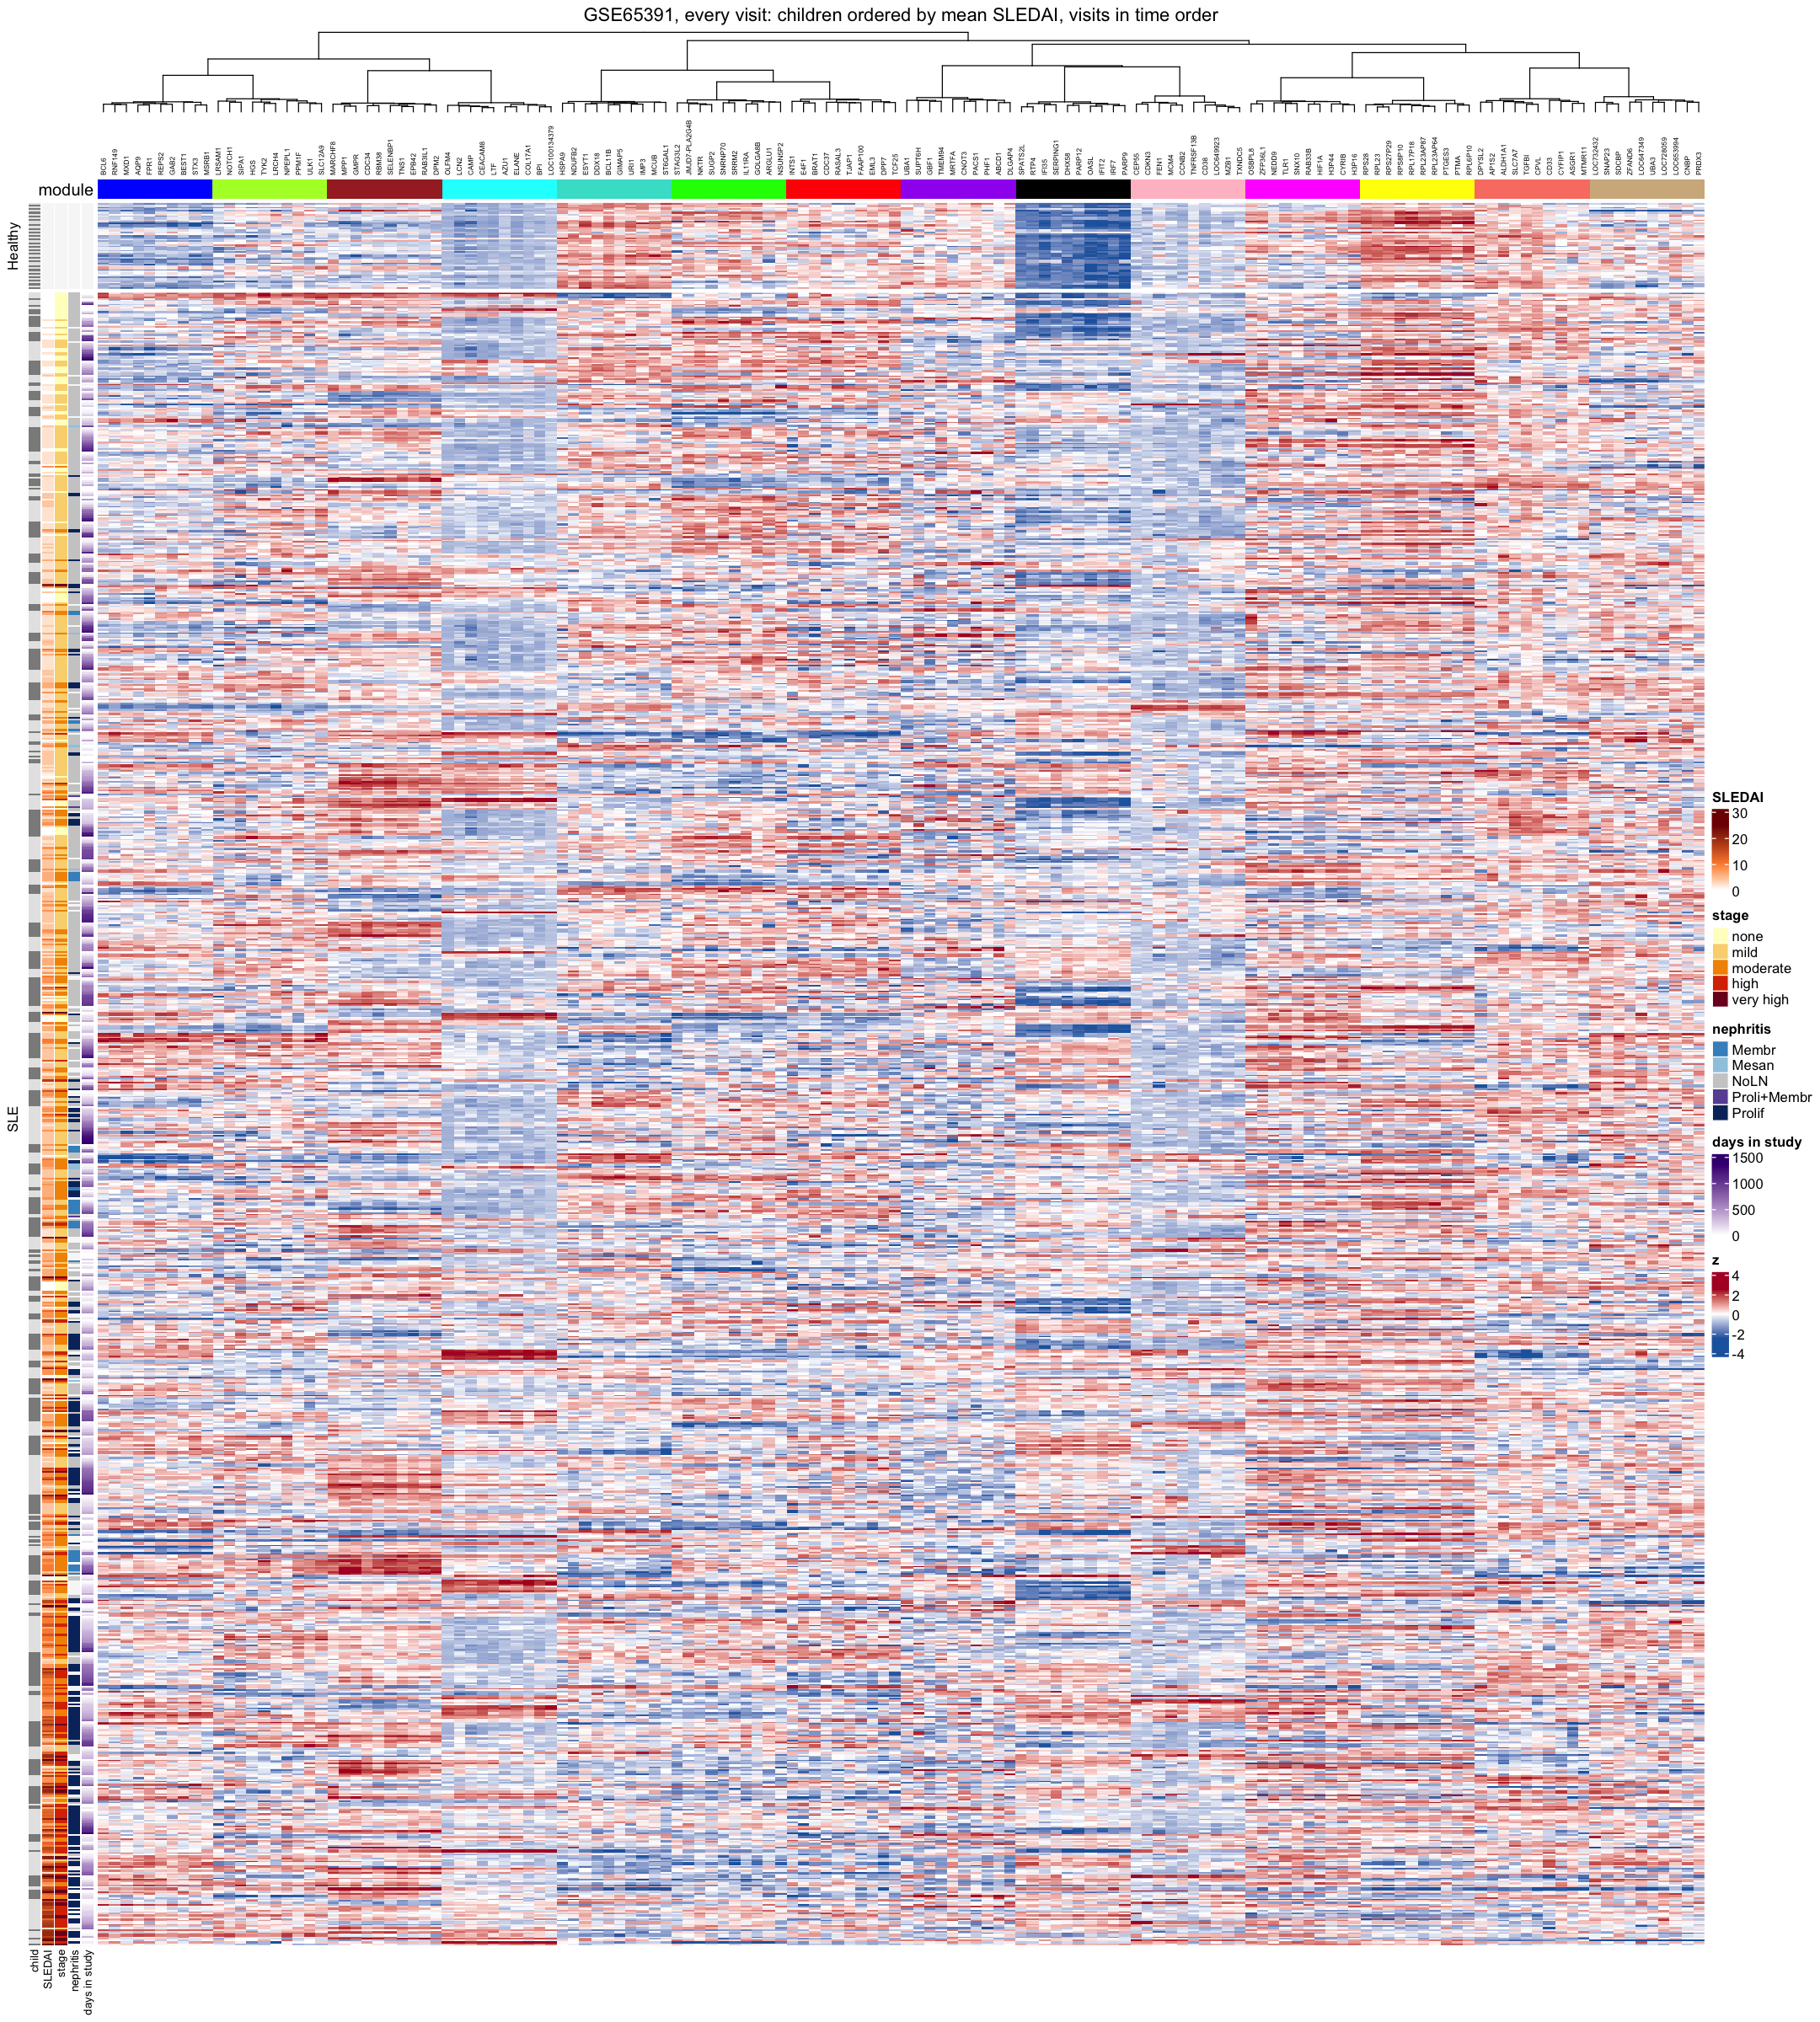

In [4]:
options(repr.plot.width = 18, repr.plot.height = 20)
figure <- function() draw_ordered(orders$by_mean_sledai, "GSE65391, every visit: children ordered by mean SLEDAI, visits in time order")
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "07b_GSE65391_RNA_array_visits_ordered_by_mean_sledai.png"), width = 18, height = 20, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- `draw_ordered(orders$by_mean_sledai, ...)` draws the figure with the children ordered by mean SLEDAI.
- The figure loop is explained in notebook 04.

**Figure 2.** Children ordered by the Ward tree of their mean hub-gene profiles.

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.



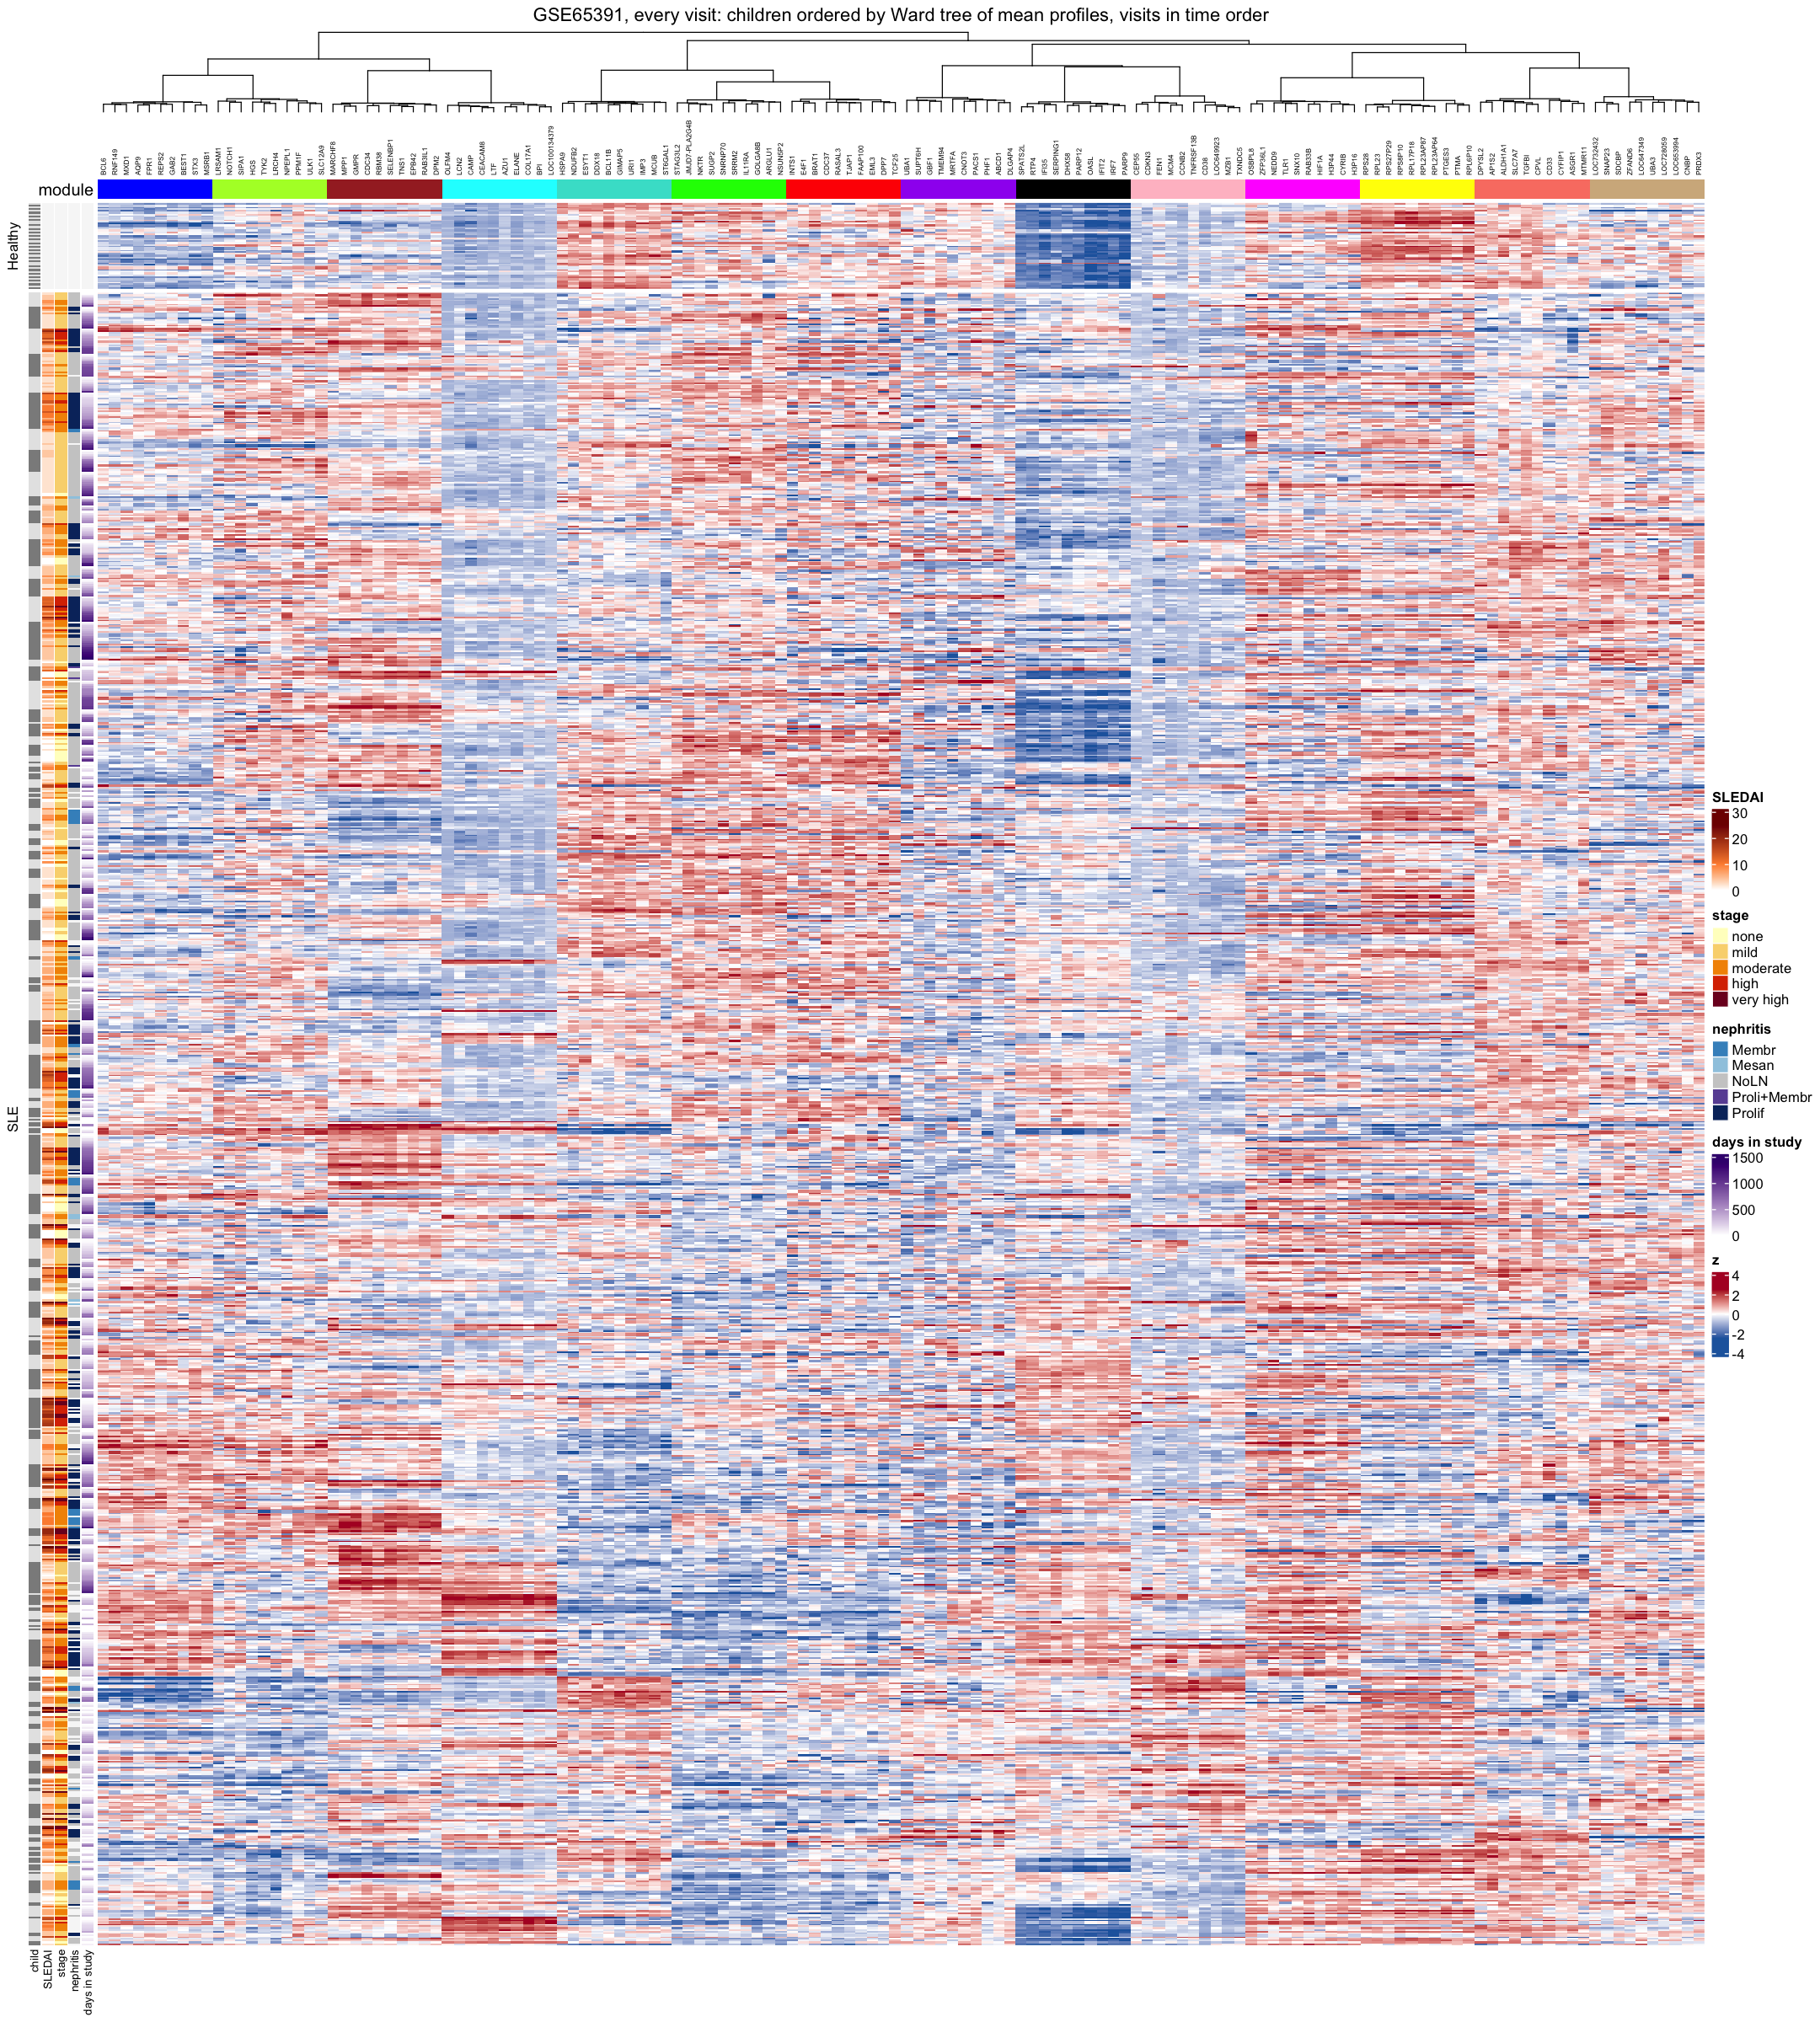

In [5]:
options(repr.plot.width = 18, repr.plot.height = 20)
figure <- function() draw_ordered(orders$by_child_ward_tree, "GSE65391, every visit: children ordered by Ward tree of mean profiles, visits in time order")
for (device in c("inline", "png")) {               # shown here, and saved as a 300 dpi PNG
  if (device == "png") png(fig("GSE65391", "07b_GSE65391_RNA_array_visits_ordered_by_child_ward_tree.png"), width = 18, height = 20, units = "in", res = 300)
  out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
  if (device == "png") invisible(dev.off())
}

**Explanation**
- The same figure with the children in the leaf order of the Ward tree of their mean profiles.